In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('data/superstore.csv', encoding='latin-1', on_bad_lines='skip')

# Basic inspection
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())

# Fix date columns
df['Order_Date'] = pd.to_datetime(df['Order Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship Date'])

# Add useful columns
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Ship_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

print("✅ Done. Shape:", df.shape)
print("Years in data:", df['Order_Year'].unique())
print("Null values:", df.isnull().sum().sum())

(9994, 21)
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
0
✅ Done. Shape: (9994, 26)
Years in d

In [6]:
# Step 1 - check what columns actually loaded
print(df.shape)
print(df.columns.tolist())

(26, 1)
['PK\x03\x04\x14']


In [3]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False)

# Q1: Profit by Category
q1 = pd.read_sql("""
  SELECT Category,
         ROUND(SUM(Sales),2) AS total_sales,
         ROUND(SUM(Profit),2) AS total_profit,
         ROUND(SUM(Profit)*100.0/SUM(Sales),2) AS profit_margin_pct
  FROM sales
  GROUP BY Category
  ORDER BY total_profit DESC
""", conn)

# Q2: Loss-making Sub-Categories
q2 = pd.read_sql("""
  SELECT "Sub-Category",
         ROUND(SUM(Profit),2) AS total_profit,
         ROUND(SUM(Sales),2) AS total_sales
  FROM sales
  GROUP BY "Sub-Category"
  ORDER BY total_profit ASC
  LIMIT 5
""", conn)

# Q3: Revenue by Region
q3 = pd.read_sql("""
  SELECT Region,
         ROUND(SUM(Sales),2) AS total_sales,
         ROUND(SUM(Profit),2) AS total_profit,
         COUNT(DISTINCT "Order ID") AS total_orders
  FROM sales
  GROUP BY Region
  ORDER BY total_sales DESC
""", conn)

# Q4: Year-over-Year Revenue
q4 = pd.read_sql("""
  SELECT Order_Year,
         ROUND(SUM(Sales),2) AS annual_revenue,
         ROUND(SUM(Profit),2) AS annual_profit
  FROM sales
  GROUP BY Order_Year
  ORDER BY Order_Year
""", conn)

# Q5: Top 10 Customers
q5 = pd.read_sql("""
  SELECT "Customer Name",
         ROUND(SUM(Sales),2) AS total_spend,
         COUNT(DISTINCT "Order ID") AS total_orders
  FROM sales
  GROUP BY "Customer Name"
  ORDER BY total_spend DESC
  LIMIT 10
""", conn)

print("=== Q1: Profit by Category ===")
print(q1)
print("\n=== Q2: Worst Sub-Categories ===")
print(q2)
print("\n=== Q3: Revenue by Region ===")
print(q3)
print("\n=== Q4: Year-over-Year ===")
print(q4)
print("\n=== Q5: Top 10 Customers ===")
print(q5)

=== Q1: Profit by Category ===
          Category  total_sales  total_profit  profit_margin_pct
0       Technology    836154.03     145454.95              17.40
1  Office Supplies    719047.03     122490.80              17.04
2        Furniture    741999.80      18451.27               2.49

=== Q2: Worst Sub-Categories ===
  Sub-Category  total_profit  total_sales
0       Tables     -17725.48    206965.53
1    Bookcases      -3472.56    114880.00
2     Supplies      -1189.10     46673.54
3    Fasteners        949.52      3024.28
4     Machines       3384.76    189238.63

=== Q3: Revenue by Region ===
    Region  total_sales  total_profit  total_orders
0     West    725457.82     108418.45          1611
1     East    678781.24      91522.78          1401
2  Central    501239.89      39706.36          1175
3    South    391721.91      46749.43           822

=== Q4: Year-over-Year ===
   Order_Year  annual_revenue  annual_profit
0        2014       484247.50       49543.97
1        2015 

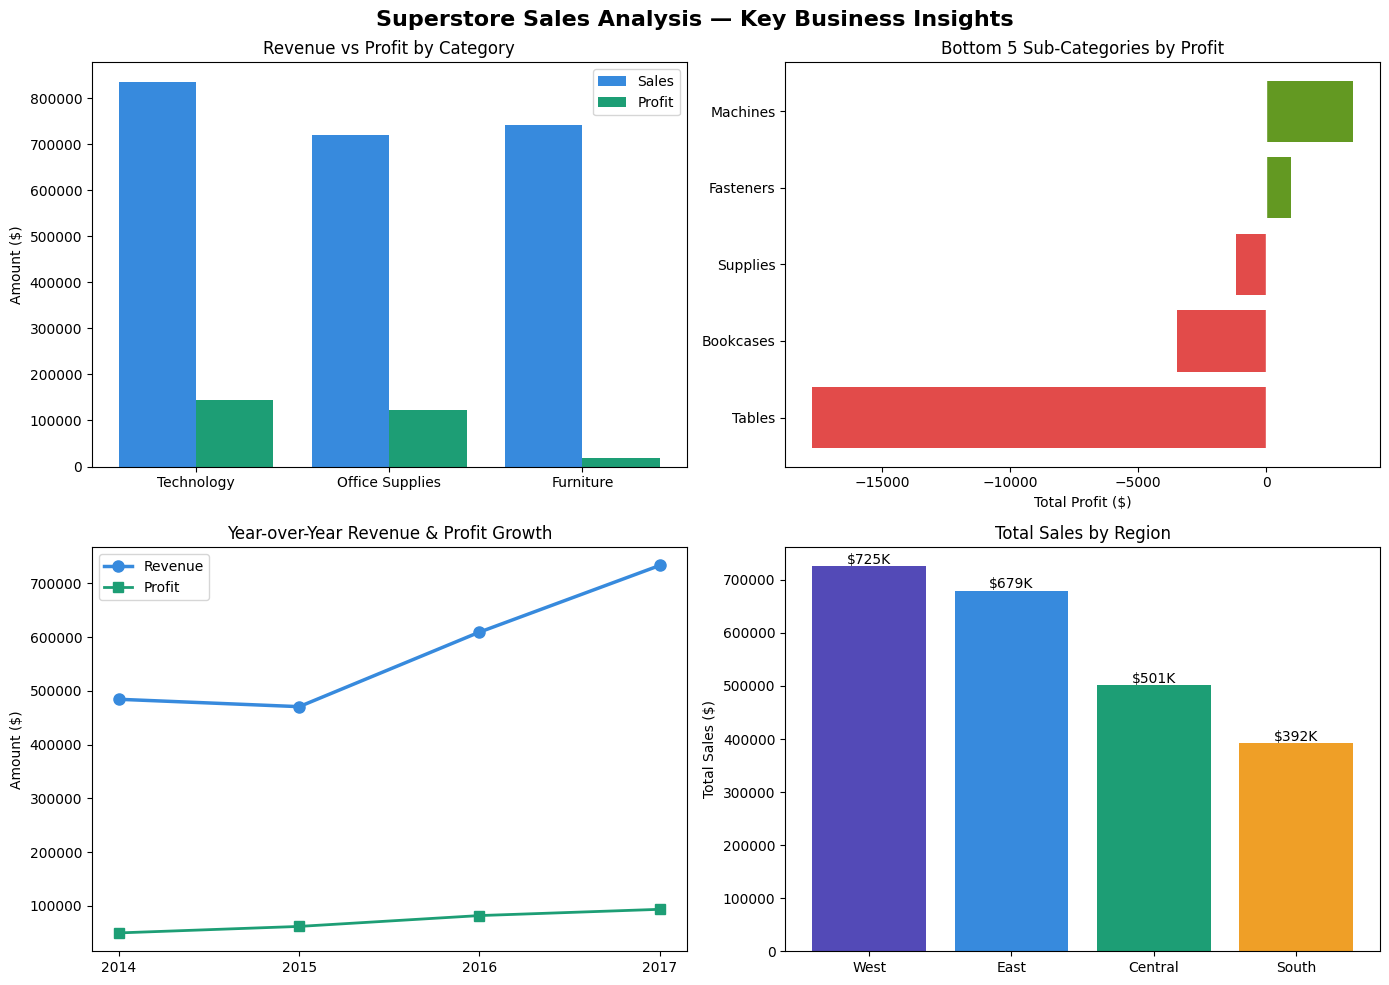

✅ Chart saved to outputs/superstore_dashboard.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superstore Sales Analysis — Key Business Insights', fontsize=16, fontweight='bold')

# Chart 1: Revenue & Profit by Category
x = range(len(q1['Category']))
bars1 = axes[0,0].bar([i-0.2 for i in x], q1['total_sales'], 0.4, label='Sales', color='#378ADD')
bars2 = axes[0,0].bar([i+0.2 for i in x], q1['total_profit'], 0.4, label='Profit', color='#1D9E75')
axes[0,0].set_title('Revenue vs Profit by Category')
axes[0,0].set_xticks(list(x))
axes[0,0].set_xticklabels(q1['Category'])
axes[0,0].legend()
axes[0,0].set_ylabel('Amount ($)')

# Chart 2: Loss-making Sub-Categories
colors = ['#E24B4A' if x < 0 else '#639922' for x in q2['total_profit']]
axes[0,1].barh(q2['Sub-Category'], q2['total_profit'], color=colors)
axes[0,1].set_title('Bottom 5 Sub-Categories by Profit')
axes[0,1].axvline(0, color='white', linewidth=1)
axes[0,1].set_xlabel('Total Profit ($)')

# Chart 3: YoY Revenue Growth
axes[1,0].plot(q4['Order_Year'], q4['annual_revenue'],
               marker='o', color='#378ADD', linewidth=2.5, markersize=8, label='Revenue')
axes[1,0].plot(q4['Order_Year'], q4['annual_profit'],
               marker='s', color='#1D9E75', linewidth=2, markersize=7, label='Profit')
axes[1,0].set_title('Year-over-Year Revenue & Profit Growth')
axes[1,0].set_ylabel('Amount ($)')
axes[1,0].legend()
axes[1,0].set_xticks(q4['Order_Year'])

# Chart 4: Sales by Region
axes[1,1].bar(q3['Region'], q3['total_sales'], color=['#534AB7','#378ADD','#1D9E75','#EF9F27'])
axes[1,1].set_title('Total Sales by Region')
axes[1,1].set_ylabel('Total Sales ($)')
for i, v in enumerate(q3['total_sales']):
    axes[1,1].text(i, v + 5000, f'${v/1000:.0f}K', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/superstore_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/superstore_dashboard.png")